# EDA: Недвижимость в Санкт-Петербурге и Москве

Этот ноутбук содержит разведочный анализ данных о недвижимости, собранных из различных источников.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Настройка стилей
plt.style.use('default')
sns.set_palette("husl")

# Загрузка данных
df = pd.read_csv('../data/raw/unified_real_estate.csv')
print(f"Всего записей: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")

Всего записей: 35471
Колонки: ['id', 'text', 'price', 'price_currency', 'location', 'city', 'property_type', 'area_sqm', 'living_area_sqm', 'kitchen_area_sqm', 'rooms', 'floor', 'total_floors', 'building_type', 'build_year', 'label', 'source', 'collected_at', 'url', 'date_posted', 'metadata']


## 1. Общая информация о датасете

In [2]:
# Общая статистика
print("=== ОБЩАЯ ИНФОРМАЦИЯ ===")
print(f"Всего записей: {len(df)}")
print(f"\nРаспределение по городам:")
print(df['city'].value_counts())
print(f"\nРаспределение по типу сделки:")
print(df['label'].value_counts())

# Процентное распределение
print("\n=== ПРОЦЕНТНОЕ РАСПРЕДЕЛЕНИЕ ===")
print(df['city'].value_counts(normalize=True) * 100)

=== ОБЩАЯ ИНФОРМАЦИЯ ===
Всего записей: 35471

Распределение по городам:
city
Москва             30471
Санкт-Петербург     5000
Name: count, dtype: int64

Распределение по типу сделки:
label
Продажа    34728
Аренда       743
Name: count, dtype: int64

=== ПРОЦЕНТНОЕ РАСПРЕДЕЛЕНИЕ ===
city
Москва             85.903978
Санкт-Петербург    14.096022
Name: proportion, dtype: float64


## 2. Распределение цен

=== СТАТИСТИКА ЦЕН ===
                   count          mean           std       min         25%  \
city                                                                         
Москва           30471.0  7.123035e+06  4.780111e+06  100000.0  4740002.00   
Санкт-Петербург   5000.0  6.907856e+06  5.680114e+06    9000.0  3277496.75   

                       50%         75%          max  
city                                                 
Москва           6274411.0  8300000.00  111111112.0  
Санкт-Петербург  5857363.5  9395097.75   44316204.0  


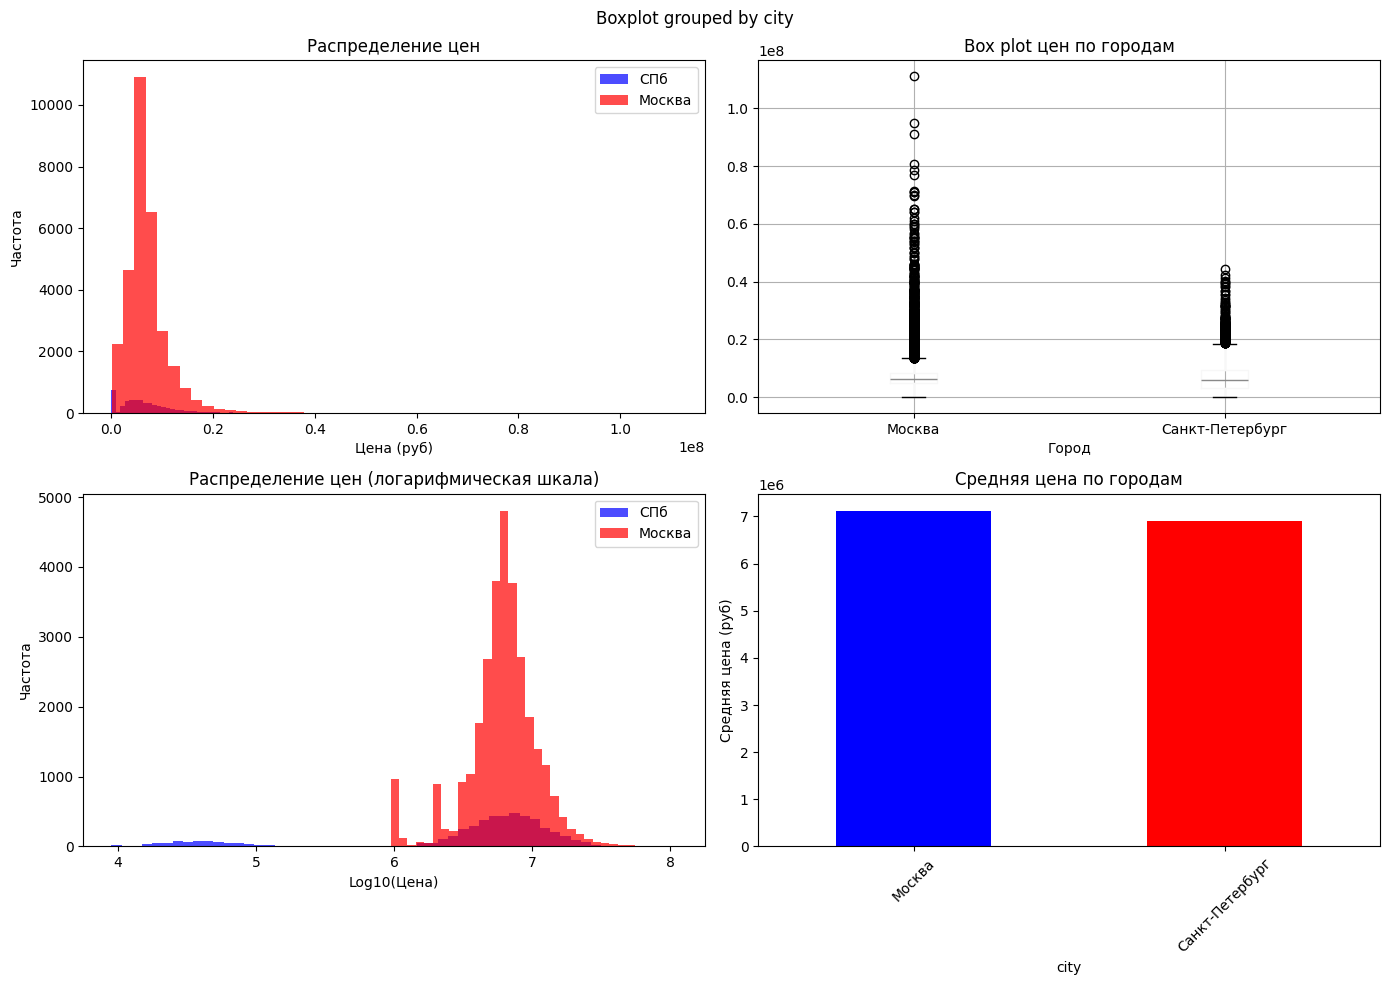

In [3]:
# Статистика цен
print("=== СТАТИСТИКА ЦЕН ===")
print(df.groupby('city')['price'].describe())

# Визуализация распределения цен
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма цен (все данные)
axes[0, 0].hist(df[df['city'] == 'Санкт-Петербург']['price'], bins=50, alpha=0.7, label='СПб', color='blue')
axes[0, 0].hist(df[df['city'] == 'Москва']['price'], bins=50, alpha=0.7, label='Москва', color='red')
axes[0, 0].set_xlabel('Цена (руб)')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_title('Распределение цен')
axes[0, 0].legend()

# Box plot
df.boxplot(column='price', by='city', ax=axes[0, 1])
axes[0, 1].set_title('Box plot цен по городам')
axes[0, 1].set_xlabel('Город')

# Логарифмическая шкала
axes[1, 0].hist(np.log10(df[df['city'] == 'Санкт-Петербург']['price']), bins=50, alpha=0.7, label='СПб', color='blue')
axes[1, 0].hist(np.log10(df[df['city'] == 'Москва']['price']), bins=50, alpha=0.7, label='Москва', color='red')
axes[1, 0].set_xlabel('Log10(Цена)')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_title('Распределение цен (логарифмическая шкала)')
axes[1, 0].legend()

# Средняя цена по городам
avg_price = df.groupby('city')['price'].mean()
avg_price.plot(kind='bar', ax=axes[1, 1], color=['blue', 'red'])
axes[1, 1].set_title('Средняя цена по городам')
axes[1, 1].set_ylabel('Средняя цена (руб)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Распределение площади

=== СТАТИСТИКА ПЛОЩАДИ ===
                   count       mean        std   min   25%   50%     75%  \
city                                                                       
Москва           30471.0  54.214269  38.031487   0.0  38.0  49.0  63.000   
Санкт-Петербург   5000.0  59.175840  25.671649  15.0  40.6  53.3  72.025   

                    max  
city                     
Москва           5326.0  
Санкт-Петербург   209.0  


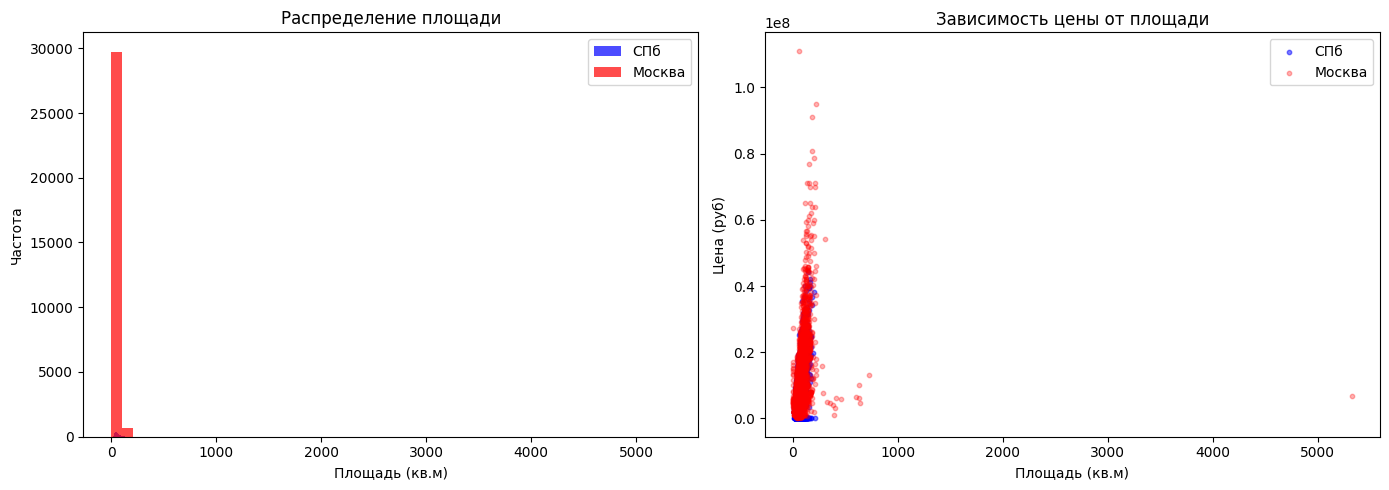

In [4]:
# Статистика площади
print("=== СТАТИСТИКА ПЛОЩАДИ ===")
print(df.groupby('city')['area_sqm'].describe())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма площади
axes[0].hist(df[df['city'] == 'Санкт-Петербург']['area_sqm'].dropna(), bins=50, alpha=0.7, label='СПб', color='blue')
axes[0].hist(df[df['city'] == 'Москва']['area_sqm'].dropna(), bins=50, alpha=0.7, label='Москва', color='red')
axes[0].set_xlabel('Площадь (кв.м)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение площади')
axes[0].legend()

# Scatter plot: Площадь vs Цена
spb_data = df[df['city'] == 'Санкт-Петербург']
msk_data = df[df['city'] == 'Москва']
axes[1].scatter(spb_data['area_sqm'], spb_data['price'], alpha=0.5, label='СПб', color='blue', s=10)
axes[1].scatter(msk_data['area_sqm'], msk_data['price'], alpha=0.3, label='Москва', color='red', s=10)
axes[1].set_xlabel('Площадь (кв.м)')
axes[1].set_ylabel('Цена (руб)')
axes[1].set_title('Зависимость цены от площади')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/area_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Распределение по количеству комнат

=== РАСПРЕДЕЛЕНИЕ ПО КОМНАТАМ ===
rooms            0      1     2     3    4   5   6   7   8   9   10  17  19
city                                                                       
Москва           14  17174  8132  4675  418  40   9   1   3   1   2   1   1
Санкт-Петербург   0   1789  1723   981  415  92   0   0   0   0   0   0   0


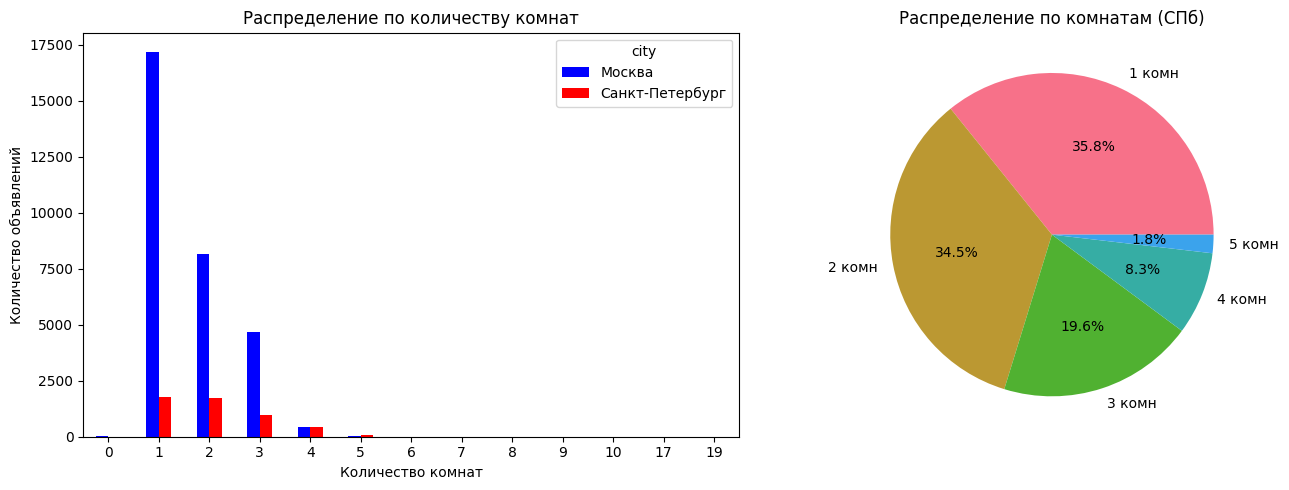

In [5]:
# Статистика по комнатам
print("=== РАСПРЕДЕЛЕНИЕ ПО КОМНАТАМ ===")
room_dist = df.groupby(['city', 'rooms']).size().unstack(fill_value=0)
print(room_dist)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма
room_dist.T.plot(kind='bar', ax=axes[0], color=['blue', 'red'])
axes[0].set_title('Распределение по количеству комнат')
axes[0].set_xlabel('Количество комнат')
axes[0].set_ylabel('Количество объявлений')
axes[0].tick_params(axis='x', rotation=0)

# Круговая диаграмма для СПб
spb_rooms = df[df['city'] == 'Санкт-Петербург']['rooms'].value_counts().sort_index()
axes[1].pie(spb_rooms.values, labels=[f'{int(r)} комн' for r in spb_rooms.index], autopct='%1.1f%%')
axes[1].set_title('Распределение по комнатам (СПб)')

plt.tight_layout()
plt.savefig('../data/processed/rooms_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Анализ по районам (Санкт-Петербург)

=== РАЙОНЫ САНКТ-ПЕТЕРБУРГА ===
Количество уникальных районов: 14

Топ-10 районов по количеству объявлений:
location
Центральный          654
Адмиралтейский       528
Василеостровский     454
Петроградский        423
Калининский          376
Приморский           372
Выборгский           356
Московский           302
Кировский            297
Красногвардейский    289
Name: count, dtype: int64

Средняя цена по районам (топ-10):
location
Центральный         1.019815e+07
Петроградский       1.001005e+07
Адмиралтейский      9.287748e+06
Василеостровский    8.349002e+06
Приморский          6.394194e+06
Выборгский          5.924949e+06
Калининский         5.241675e+06
Невский             5.002388e+06
Московский          4.876177e+06
Фрунзенский         4.839275e+06
Name: price, dtype: float64


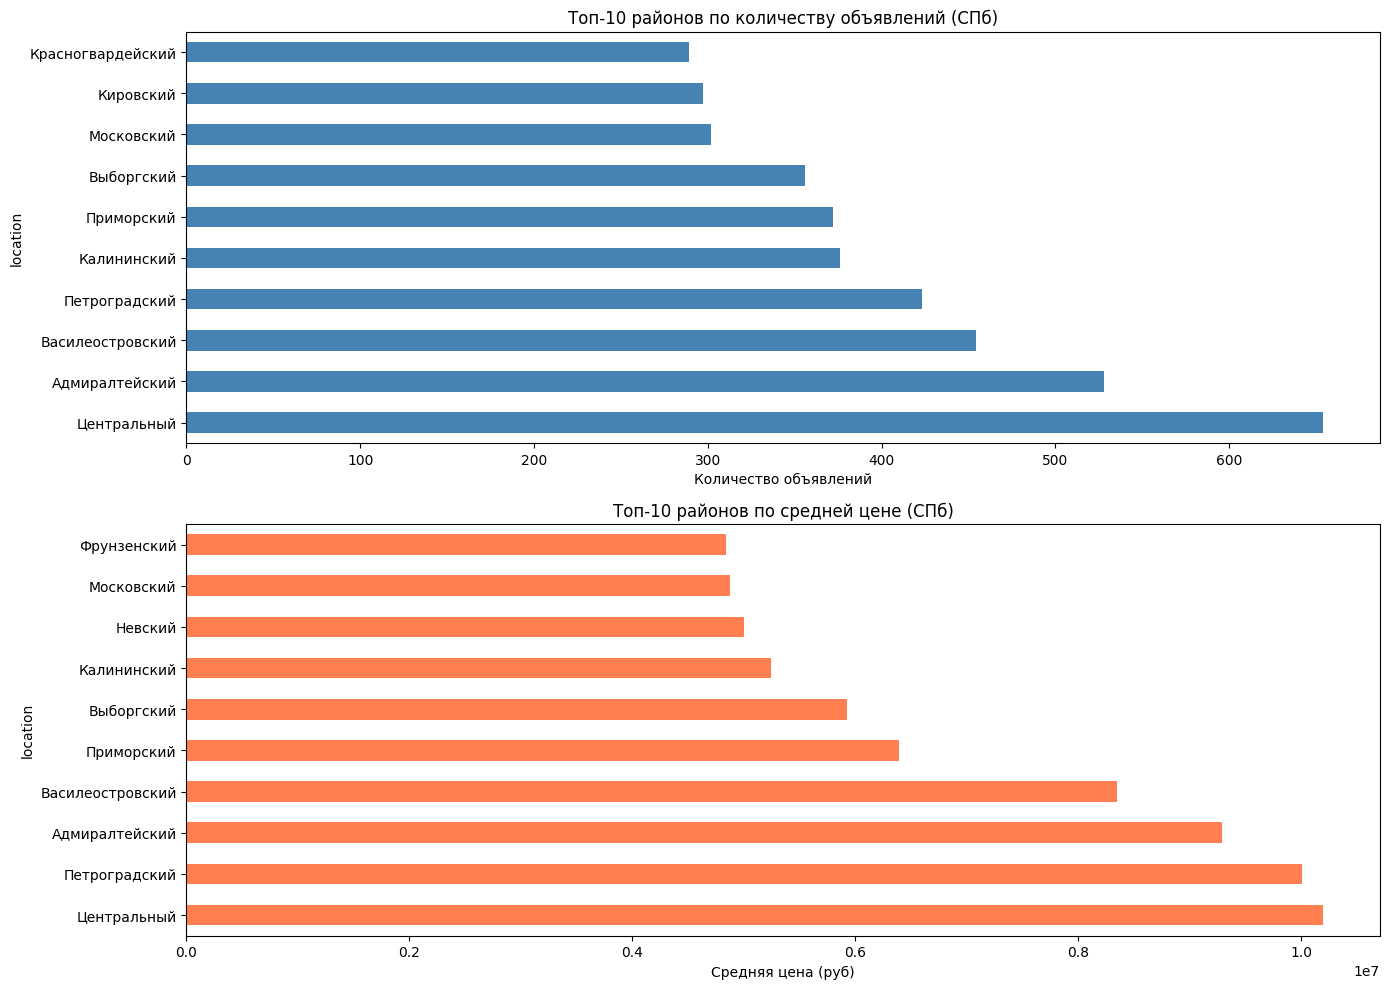

In [6]:
# Фильтрация данных по СПб
df_spb = df[df['city'] == 'Санкт-Петербург']

print("=== РАЙОНЫ САНКТ-ПЕТЕРБУРГА ===")
print(f"Количество уникальных районов: {df_spb['location'].nunique()}")
print("\nТоп-10 районов по количеству объявлений:")
print(df_spb['location'].value_counts().head(10))

# Средняя цена по районам
print("\nСредняя цена по районам (топ-10):")
avg_price_by_district = df_spb.groupby('location')['price'].mean().sort_values(ascending=False)
print(avg_price_by_district.head(10))

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Количество объявлений по районам
df_spb['location'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Топ-10 районов по количеству объявлений (СПб)')
axes[0].set_xlabel('Количество объявлений')

# Средняя цена по районам
avg_price_by_district.head(10).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Топ-10 районов по средней цене (СПб)')
axes[1].set_xlabel('Средняя цена (руб)')

plt.tight_layout()
plt.savefig('../data/processed/spb_districts.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Анализ текстов описаний

=== СТАТИСТИКА ДЛИНЫ ТЕКСТОВ ===
                   count        mean        std    min    25%    50%    75%  \
city                                                                          
Москва           30471.0  167.404056  10.511605  137.0  164.0  169.0  175.0   
Санкт-Петербург   5000.0  188.136200  24.727384  123.0  195.0  197.0  200.0   

                   max  
city                    
Москва           189.0  
Санкт-Петербург  206.0  

Топ-20 слов в описаниях (СПб):
  комнатная: 5000
  квартира: 5000
  районе: 5000
  санкт: 5000
  петербурга: 5000
  общая: 5000
  площадь: 5000
  этаж: 5000
  цена: 5000
  руб: 5000
  продается: 4257
  жилая: 4257
  кухня: 4257
  дом: 4257
  года: 4257
  постройки: 4257
  монолитный: 1494
  кирпичный: 1281
  панельный: 1046
  сдается: 743


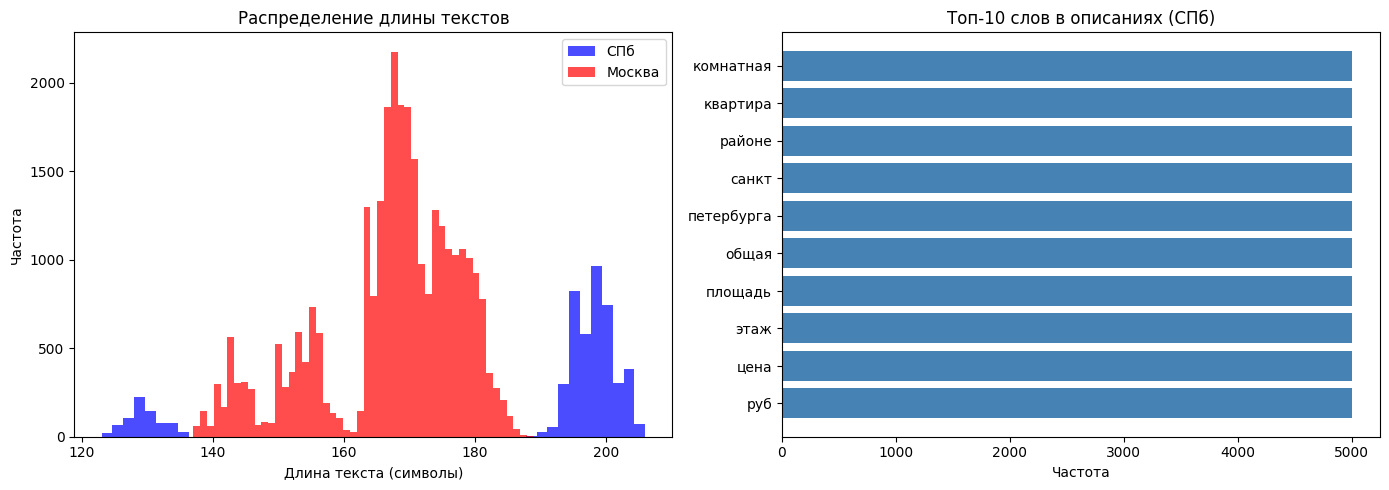

In [7]:
# Анализ длины текстов
df['text_length'] = df['text'].str.len()

print("=== СТАТИСТИКА ДЛИНЫ ТЕКСТОВ ===")
print(df.groupby('city')['text_length'].describe())

# Топ-20 слов
def get_top_words(texts, n=20):
    all_text = ' '.join(texts.fillna('').astype(str)).lower()
    words = re.findall(r'\b[\wа-яА-Я]{3,}\b', all_text)
    return Counter(words).most_common(n)

print("\nТоп-20 слов в описаниях (СПб):")
spb_texts = df[df['city'] == 'Санкт-Петербург']['text']
top_words_spb = get_top_words(spb_texts)
for word, count in top_words_spb:
    print(f"  {word}: {count}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Длина текстов
axes[0].hist(df[df['city'] == 'Санкт-Петербург']['text_length'], bins=50, alpha=0.7, label='СПб', color='blue')
axes[0].hist(df[df['city'] == 'Москва']['text_length'], bins=50, alpha=0.7, label='Москва', color='red')
axes[0].set_xlabel('Длина текста (символы)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение длины текстов')
axes[0].legend()

# Топ слова
words, counts = zip(*top_words_spb[:10])
axes[1].barh(range(len(words)), counts, color='steelblue')
axes[1].set_yticks(range(len(words)))
axes[1].set_yticklabels(words)
axes[1].set_xlabel('Частота')
axes[1].set_title('Топ-10 слов в описаниях (СПб)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/processed/text_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Корреляционный анализ

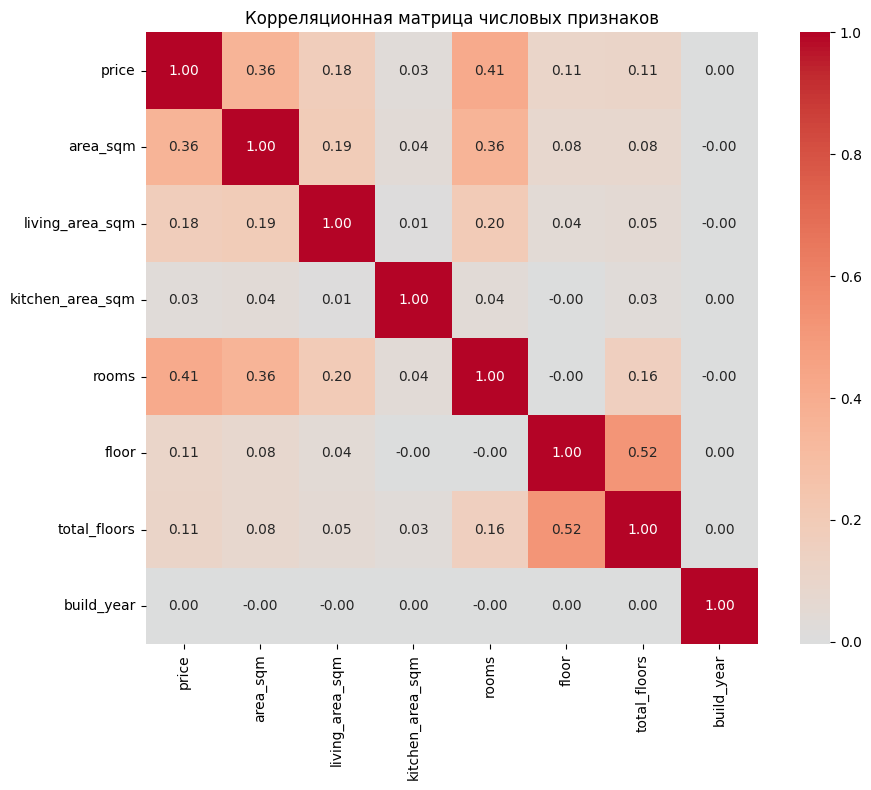

Корреляция с ценой:
price               1.000000
rooms               0.409485
area_sqm            0.358076
living_area_sqm     0.179793
total_floors        0.109982
floor               0.105431
kitchen_area_sqm    0.030077
build_year          0.002132
Name: price, dtype: float64


In [8]:
# Выбор числовых колонок
numeric_cols = ['price', 'area_sqm', 'living_area_sqm', 'kitchen_area_sqm', 
                'rooms', 'floor', 'total_floors', 'build_year']

# Корреляционная матрица
corr_matrix = df[numeric_cols].corr()

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Корреляция с ценой:")
print(corr_matrix['price'].sort_values(ascending=False))

## 8. Анализ типов зданий

=== ТИПЫ ЗДАНИЙ ===
building_type
Панельный     15434
Другой         9572
Монолитный     4748
Блочный        1850
Деревянный     1561
Кирпичный      1503
Пеноблок        803
Name: count, dtype: int64

Средняя цена по типам зданий:
building_type
Блочный       9.155484e+06
Пеноблок      7.979828e+06
Монолитный    7.888425e+06
Панельный     7.071725e+06
Кирпичный     7.006129e+06
Деревянный    6.483122e+06
Другой        6.371733e+06
Name: price, dtype: float64


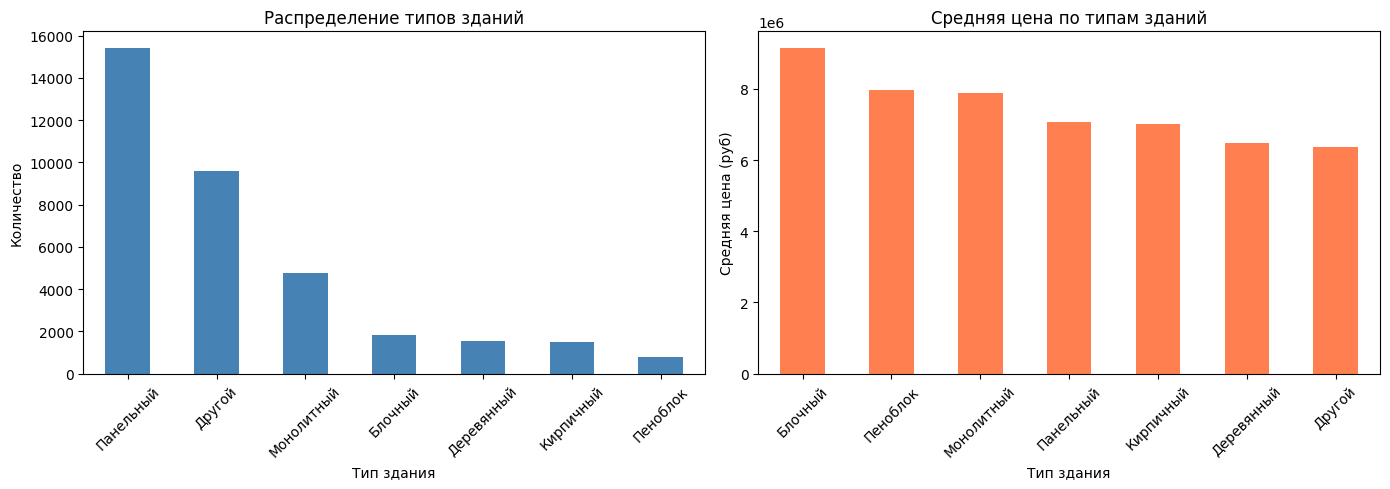

In [ ]:

print("=== ТИПЫ ЗДАНИЙ ===")
print(df['building_type'].value_counts())
print("\nСредняя цена по типам зданий:")
price_by_type = df.groupby('building_type')['price'].mean().sort_values(ascending=False)
print(price_by_type)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['building_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Распределение типов зданий')
axes[0].set_xlabel('Тип здания')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

price_by_type.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Средняя цена по типам зданий')
axes[1].set_xlabel('Тип здания')
axes[1].set_ylabel('Средняя цена (руб)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/building_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Выводы

На основе проведенного анализа:

1. **Цены**: Москва имеет более высокие цены на недвижимость по сравнению со Санкт-Петербургом
2. **Площадь**: Распределение площади схоже в обоих городах, преобладают квартиры 35-80 кв.м
3. **Комнаты**: Наиболее популярны 1- и 2-комнатные квартиры
4. **Районы**: В СПб лидируют по количеству объявлений Центральный, Адмиралтейский и Василеостровский районы
5. **Типы зданий**: Преобладают монолитные и кирпичные дома